<a href="https://colab.research.google.com/github/kshirsagar-mahesh/CSL701-Roll_No_Machine-Learning-Lab/blob/main/MLEXP2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mahesh Sakharam Kshirsagar
BECSE-27
CS02

**Aim:** To implement a Simple Linear Regression model using Python and predict MPG from Horsepower using OLS.



**Objectives**
* Understand SLR
* Load/preprocess dataset
* Perform EDA
* Compute OLS coefficients
* Evaluate with SSE, MSE, R²
* Visualize regression and residual plots















**Software Requirements**
*  Python 3.x

*  Jupyter/Colab/VS Code


*  Libraries: pandas, numpy, matplotlib, seaborn








**Theory**

Linear regression models the relationship between a target continuous variable Y and an input feature vector X using a linear equation:




$$
\hat{y} = w_0 + w_1 x_1
$$

In matrix form, including the bias/intercept term $X_0=1:$

$$\hat{y} = Xw$$

To find the optimal weight vector wˆ, the Ordinary Least Squares (OLS) method minimizes the Sum of Squared Errors (SSE) between actual target values y and predicted values  $ yˆ:$




$$SSE=\sum_{i=1}^{N}(y_i-\hat{y}_i)^2=(y-Xw)^T(y-Xw)$$.

Solving for w analytically yields the normal equation:

$$
\hat{w}=(X^TX)^{-1}X^Ty
$$


**Note:-** The inverse $(X^TX)^{-1}$ exists only if the matrix $X^TX$ is non-singular (i.e., its determinant is non-zero).









1. Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

2. Load Auto MPG dataset

In [ ]:
# Read the CSV file

df = pd.read_csv("auto-mpg.csv")
df.head()


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


3. Inspect and clean data

In [ ]:
# Display the number of rows and columns
print("Shape of dataset:", df.shape)

# Display the column names
print("\nColumn names:")
print(df.columns)

# Display information about the dataset
print("\nDataset information:")
df.info()

# Check for missing values in each column
print("\nMissing values:")
print(df.isnull().sum())

Shape of dataset: (398, 9)

Column names:
Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model year', 'origin', 'car name'],
      dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB

Missing values:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
orig

4. Select horsepower and mpg

In [ ]:
# Convert horsepower to numeric
# Invalid values such as '?' will become NaN
df["horsepower"] = pd.to_numeric(df["horsepower"], errors="coerce")

# Remove rows containing missing values
df = df.dropna()

# Reset the index after removing rows
df = df.reset_index(drop=True)

# Check the cleaned dataset
print("Shape after cleaning:", df.shape)

Shape after cleaning: (392, 9)


In [ ]:
# Select horsepower as the independent variable (X)
# We will use horsepower to predict MPG
X = df["horsepower"]

# Select mpg as the dependent/target variable (y)
y = df["mpg"]

# Display the selected variables
print("Horsepower:")
print(X.head())

print("\nMPG:")
print(y.head())

Horsepower:
0    130.0
1    165.0
2    150.0
3    150.0
4    140.0
Name: horsepower, dtype: float64

MPG:
0    18.0
1    15.0
2    18.0
3    16.0
4    17.0
Name: mpg, dtype: float64


5. Plot scatter graph

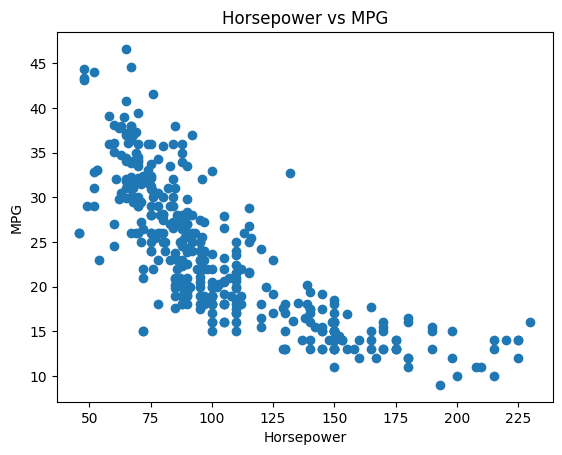

In [ ]:
# Create a scatter plot
# X-axis = Horsepower
# Y-axis = MPG
plt.scatter(X, y)

# Give a title to the graph
plt.title("Horsepower vs MPG")

# Label the X-axis
plt.xlabel("Horsepower")

# Label the Y-axis
plt.ylabel("MPG")

# Display the graph
plt.show()

6. Add bias term

In [ ]:
# Convert X into a NumPy array
X_array = X.values

# Add a column of 1s as the bias/intercept term
# This allows our regression equation to have an intercept
X_bias = np.column_stack((np.ones(len(X_array)), X_array))

# Display the first 5 rows
print(X_bias[:5])

[[  1. 130.]
 [  1. 165.]
 [  1. 150.]
 [  1. 150.]
 [  1. 140.]]


7. Compute correlation

In [ ]:
# Calculate the correlation between horsepower and MPG
correlation = df["horsepower"].corr(df["mpg"])

# Display the correlation
print("Correlation between Horsepower and MPG:", correlation)

Correlation between Horsepower and MPG: -0.7784267838977756


8. Calculate OLS weights

In [ ]:
# Convert y into a NumPy array
y_array = y.values

# Calculate OLS weights using the normal equation:
# beta = (X^T X)^(-1) X^T y
beta = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ y_array

# Extract intercept (beta 0)
intercept = beta[0]

# Extract slope (beta 1)
slope = beta[1]

# Display the calculated values
print("Intercept (β0):", intercept)
print("Slope (β1):", slope)

Intercept (β0): 39.9358610211705
Slope (β1): -0.15784473335365387


9. Predict values

In [ ]:
# Calculate predicted MPG values using the regression equation
y_pred = X_bias @ beta

# Display the first 10 predicted values
print("First 10 predicted MPG values:")
print(y_pred[:10])

First 10 predicted MPG values:
[19.41604569 13.89148002 16.25915102 16.25915102 17.83759835  8.68260382
  5.21001968  5.99924335  4.42079602  9.94536168]


10. Compute residuals

In [ ]:
# Calculate residuals
# Residual = Actual MPG - Predicted MPG
residuals = y_array - y_pred

# Display the first 10 residuals
print("First 10 residuals:")
print(residuals[:10])

First 10 residuals:
[-1.41604569  1.10851998  1.74084898 -0.25915102 -0.83759835  6.31739618
  8.78998032  8.00075665  9.57920398  5.05463832]


11. Calculate SSE, MSE, R²

In [ ]:
# SSE = Sum of Squared Errors
# It measures the total squared difference between actual and predicted values
SSE = np.sum(residuals ** 2)

# MSE = Mean Squared Error
# It is the average squared prediction error
MSE = SSE / len(y_array)

# SST = Total Sum of Squares
# It measures the total variation in the actual MPG values
SST = np.sum((y_array - np.mean(y_array)) ** 2)

# R² = Coefficient of Determination
# It tells us how much variation in MPG is explained by horsepower
R2 = 1 - (SSE / SST)

# Display the results
print("SSE:", SSE)
print("MSE:", MSE)
print("R²:", R2)

SSE: 9385.915871932419
MSE: 23.943662938603108
R²: 0.6059482578894348


12. Plot regression and residual graphs


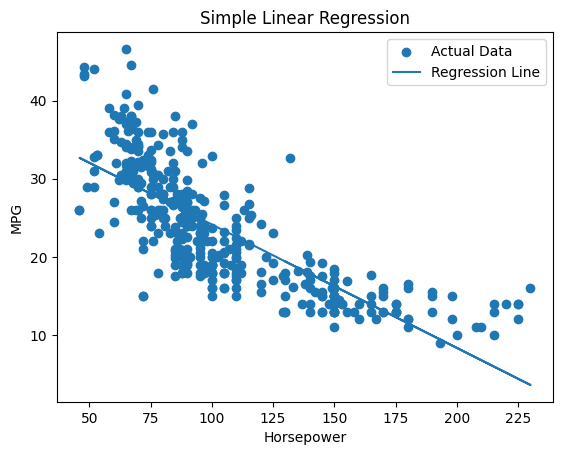

In [ ]:
# Plot the original data points
plt.scatter(X, y, label="Actual Data")

# Plot the regression line
plt.plot(X, y_pred, label="Regression Line")

# Add title and labels
plt.title("Simple Linear Regression")
plt.xlabel("Horsepower")
plt.ylabel("MPG")

# Display legend
plt.legend()

# Display graph
plt.show()

13. Interpret results.

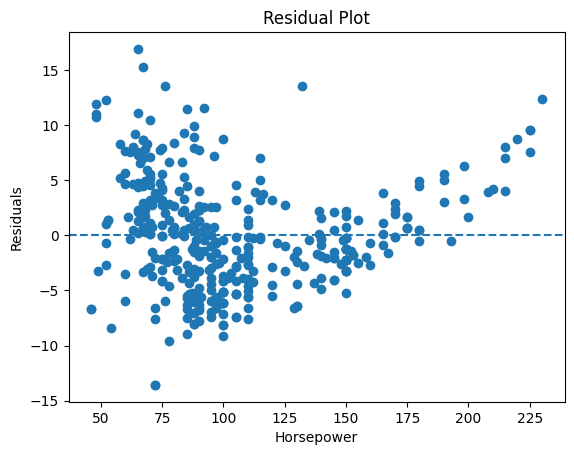

In [ ]:
# Plot horsepower against residuals
plt.scatter(X, residuals)

# Add a horizontal line at residual = 0
# Ideally, residuals should be randomly distributed around this line
plt.axhline(y=0, linestyle="--")

# Add title and labels
plt.title("Residual Plot")
plt.xlabel("Horsepower")
plt.ylabel("Residuals")

# Display graph
plt.show()

**Conclusion :-**
The experiment successfully implemented Simple Linear Regression using OLS. Horsepower showed a negative relationship with MPG, and evaluation metrics demonstrated reasonable predictive performance.
